# Verify Analytical Value Function (Full State)

**Goal**: Verify closed-form value function using Monte Carlo with full State objects.

- Uses actual grid positions for agents
- Uses actual apple positions on grid
- Compares `get_exact_value()` against Monte Carlo simulation

If this shows bias, the closed-form derivation or implementation is wrong.

In [1]:
# Parameters (can be overridden by papermill)
PICKER_PENALTY = -1.0
SEED = 42

# Fixed settings
N_AGENTS = 4
WIDTH = 9
HEIGHT = 9
GRID_SIZE = WIDTH * HEIGHT  # 81
NUM_APPLES = 40
GAMMA = 0.99

# Monte Carlo settings
MC_TRAJECTORIES = 30
MC_DEPTH = 5

In [2]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../../")

from tadd_helpers.env_functions import State, init_empty_state
from teleport_dynamic.rewards_decentralized import make_picker_penalty_reward
from teleport_dynamic.analytical import get_exact_value
from teleport_dynamic.orchard_generator import teleport_agent

np.random.seed(SEED)

# Derived parameters
P_HIT = NUM_APPLES / GRID_SIZE
ALPHA = 1 / N_AGENTS
BETA = (N_AGENTS - 1) / N_AGENTS

# Rewards
R_PICKER = PICKER_PENALTY
R_OTHER = (1 - PICKER_PENALTY) / (N_AGENTS - 1)

print(f"PICKER_PENALTY = {PICKER_PENALTY}")
print(f"SEED = {SEED}")
print(f"P_HIT = {P_HIT:.4f}")
print(f"ALPHA = {ALPHA:.4f}")
print(f"BETA = {BETA:.4f}")
print(f"R_PICKER = {R_PICKER:.4f}")
print(f"R_OTHER = {R_OTHER:.4f}")
print(f"Sum when pick = {R_PICKER + (N_AGENTS-1)*R_OTHER:.4f} (should be 1.0)")

PICKER_PENALTY = -1.0
SEED = 42
P_HIT = 0.4938
ALPHA = 0.2500
BETA = 0.7500
R_PICKER = -1.0000
R_OTHER = 0.6667
Sum when pick = 1.0000 (should be 1.0)


In [3]:
def init_random_state(height: int, width: int, n_agents: int, num_apples: int) -> State:
    """
    Create a State with random agent positions and random apple positions.
    """
    state = init_empty_state(height, width, n_agents)
    
    # Random apple positions
    state.apples = np.zeros((height, width), dtype=np.int_)
    apple_indices = np.random.choice(height * width, size=num_apples, replace=False)
    for idx in apple_indices:
        r, c = divmod(idx, width)
        state.apples[r, c] = 1
    
    # Random agent positions
    for i in range(n_agents):
        r = np.random.randint(0, height)
        c = np.random.randint(0, width)
        state.set_agent_position(i, np.array([r, c]))
    
    return state


def get_on_off_status(state: State, n_agents: int) -> np.ndarray:
    """
    Get ON/OFF status for each agent (True if on apple).
    """
    m = np.zeros(n_agents, dtype=bool)
    for i in range(n_agents):
        pos = state.agent_position(i)
        m[i] = state.apples[pos[0], pos[1]] > 0
    return m

In [4]:
def get_rewards(state: State, actor_idx: int, reward_func) -> np.ndarray:
    """
    Get rewards for ALL agents given current state and actor.
    """
    n_agents = len(state._agents)
    reward_dict = reward_func(state, actor_idx)
    rewards = np.array([reward_dict[i] for i in range(n_agents)])
    return rewards


def step(state: State, n_agents: int):
    """
    Update state in-place:
    1. Actor teleports to random position
    2. New actor selected uniformly
    
    Returns: (old_actor, new_actor)
    """
    # Get current actor (we need to track this externally)
    # This function just does the teleport for a given actor
    pass  # We'll handle this differently


def run_monte_carlo(
    initial_state: State,
    initial_actor: int,
    n_agents: int,
    reward_func,
    gamma: float,
    n_trajectories: int,
    depth: int
):
    """
    Run Monte Carlo from initial_state with initial_actor.
    
    Returns:
        mc_values: (n_agents,) average return for each agent
        reward_counts: dict tracking reward frequencies
        total_steps: total steps counted for distribution
    """
    total_returns = np.zeros(n_agents)
    
    # Track rewards for distribution verification
    reward_counts = {i: {'picker': 0, 'other': 0, 'zero': 0} for i in range(n_agents)}
    total_steps = 0
    
    for traj in range(n_trajectories):
        if traj % 1000 == 0:
            print(f"Trajectory {traj}/{n_trajectories}")
        
        # Start from the SAME initial state each trajectory
        state = initial_state.copy()
        actor = initial_actor
        
        episode_returns = np.zeros(n_agents)
        gamma_pow = 1.0
        
        for t in range(depth):
            # Get rewards for current state
            rewards = get_rewards(state, actor, reward_func)
            episode_returns += gamma_pow * rewards
            
            # Track reward distribution (skip first step since it's deterministic from initial state)
            if t > 0:
                total_steps += 1
                for i in range(n_agents):
                    if abs(rewards[i] - R_PICKER) < 1e-9:
                        reward_counts[i]['picker'] += 1
                    elif abs(rewards[i] - R_OTHER) < 1e-9:
                        reward_counts[i]['other'] += 1
                    else:
                        reward_counts[i]['zero'] += 1
            
            # Transition: actor teleports, new actor selected
            teleport_agent(state, actor)
            actor = np.random.randint(0, n_agents)
            
            gamma_pow *= gamma
            if gamma_pow < 1e-12:
                break
        
        total_returns += episode_returns
    
    mc_values = total_returns / n_trajectories
    return mc_values, reward_counts, total_steps

In [5]:
# Create initial state
initial_state = init_random_state(HEIGHT, WIDTH, N_AGENTS, NUM_APPLES)
initial_actor = np.random.randint(0, N_AGENTS)

# Get ON/OFF status for display
m = get_on_off_status(initial_state, N_AGENTS)

# Get agent positions for saving
agent_positions = [tuple(initial_state.agent_position(i)) for i in range(N_AGENTS)]

print(f"Initial state:")
print(f"  Agent positions = {agent_positions}")
print(f"  m = {m} (ON status for each agent)")
print(f"  c = {initial_actor} (actor)")
print(f"  Actor is {'ON' if m[initial_actor] else 'OFF'} apple")
print(f"  Total apples = {np.sum(initial_state.apples)}")

Initial state:
  Agent positions = [(np.int64(0), np.int64(8)), (np.int64(6), np.int64(8)), (np.int64(7), np.int64(0)), (np.int64(7), np.int64(7))]
  m = [False  True False False] (ON status for each agent)
  c = 2 (actor)
  Actor is OFF apple
  Total apples = 40


In [6]:
# Create reward function
reward_func = make_picker_penalty_reward(PICKER_PENALTY)

# Compute analytical values for each agent
analytical_values = np.zeros(N_AGENTS)
for i in range(N_AGENTS):
    analytical_values[i] = get_exact_value(
        initial_state, initial_actor, i, reward_func, GAMMA
    )

print(f"Analytical values:")
for i, v in enumerate(analytical_values):
    print(f"  Agent {i}: {v:.6f}")

Analytical values:
  Agent 0: 12.704782
  Agent 1: 11.102841
  Agent 2: 11.913700
  Agent 3: 12.704782


In [7]:
# Run Monte Carlo
print(f"\nRunning Monte Carlo ({MC_TRAJECTORIES} trajectories, depth {MC_DEPTH})...")
mc_values, reward_counts, total_steps = run_monte_carlo(
    initial_state=initial_state,
    initial_actor=initial_actor,
    n_agents=N_AGENTS,
    reward_func=reward_func,
    gamma=GAMMA,
    n_trajectories=MC_TRAJECTORIES,
    depth=MC_DEPTH
)
print("Done.")


Running Monte Carlo (30 trajectories, depth 5)...
Trajectory 0/30
Done.


In [8]:
# Compare results
print(f"\n{'='*60}")
print(f"RESULTS")
print(f"{'='*60}")
print(f"{'Agent':<8} {'Analytical':<14} {'MC':<14} {'Diff':<14} {'Error %':<10}")
print(f"{'-'*60}")

results = []
for i in range(N_AGENTS):
    ana = analytical_values[i]
    mc = mc_values[i]
    diff = mc - ana
    pct = (diff / abs(ana)) * 100 if abs(ana) > 1e-9 else diff * 100
    print(f"{i:<8} {ana:<14.6f} {mc:<14.6f} {diff:<+14.6f} {pct:<+10.4f}")
    results.append({
        'agent': i,
        'analytical': ana,
        'mc': mc,
        'diff': diff,
        'pct': pct
    })

# Summary stats
mean_ana = np.mean(analytical_values)
mean_mc = np.mean(mc_values)
mean_diff = mean_mc - mean_ana
mean_pct = (mean_diff / abs(mean_ana)) * 100 if abs(mean_ana) > 1e-9 else mean_diff * 100

print(f"{'-'*60}")
print(f"{'Mean':<8} {mean_ana:<14.6f} {mean_mc:<14.6f} {mean_diff:<+14.6f} {mean_pct:<+10.4f}")


RESULTS
Agent    Analytical     MC             Diff           Error %   
------------------------------------------------------------
0        12.704782      0.735656       -11.969127     -94.2096  
1        11.102841      0.086018       -11.016823     -99.2253  
2        11.913700      0.299506       -11.614195     -97.4860  
3        12.704782      0.466662       -12.238121     -96.3269  
------------------------------------------------------------
Mean     12.106526      0.396960       -11.709566     -96.7211  


In [9]:
# Theoretical reward distribution (from stationary distribution after first step)
# P(agent i gets r_picker) = P(i is actor) * P(actor on apple) = alpha * p_hit
# P(agent i gets r_other) = P(i not actor) * P(actor on apple) = beta * p_hit
# P(agent i gets 0) = P(actor not on apple) = 1 - p_hit

p_picker_theory = ALPHA * P_HIT
p_other_theory = BETA * P_HIT
p_zero_theory = 1 - P_HIT

print(f"\nTheoretical reward distribution (per agent):")
print(f"  P(r_picker) = alpha * p_hit = {p_picker_theory:.4f}")
print(f"  P(r_other) = beta * p_hit = {p_other_theory:.4f}")
print(f"  P(0) = 1 - p_hit = {p_zero_theory:.4f}")

# Empirical distribution (aggregate across all agents)
if total_steps > 0:
    total_picker = sum(reward_counts[i]['picker'] for i in range(N_AGENTS))
    total_other = sum(reward_counts[i]['other'] for i in range(N_AGENTS))
    total_zero = sum(reward_counts[i]['zero'] for i in range(N_AGENTS))
    total_all = total_picker + total_other + total_zero
    
    p_picker_emp = total_picker / total_all if total_all > 0 else 0
    p_other_emp = total_other / total_all if total_all > 0 else 0
    p_zero_emp = total_zero / total_all if total_all > 0 else 0
    
    print(f"\nEmpirical reward distribution (from {total_steps} steps, {total_all} agent-steps):")
    print(f"  P(r_picker) = {p_picker_emp:.4f}")
    print(f"  P(r_other) = {p_other_emp:.4f}")
    print(f"  P(0) = {p_zero_emp:.4f}")
else:
    p_picker_emp = 0
    p_other_emp = 0
    p_zero_emp = 0
    print(f"\nNo steps recorded for distribution (depth too small?)")


Theoretical reward distribution (per agent):
  P(r_picker) = alpha * p_hit = 0.1235
  P(r_other) = beta * p_hit = 0.3704
  P(0) = 1 - p_hit = 0.5062

Empirical reward distribution (from 120 steps, 480 agent-steps):
  P(r_picker) = 0.1021
  P(r_other) = 0.3063
  P(0) = 0.5917


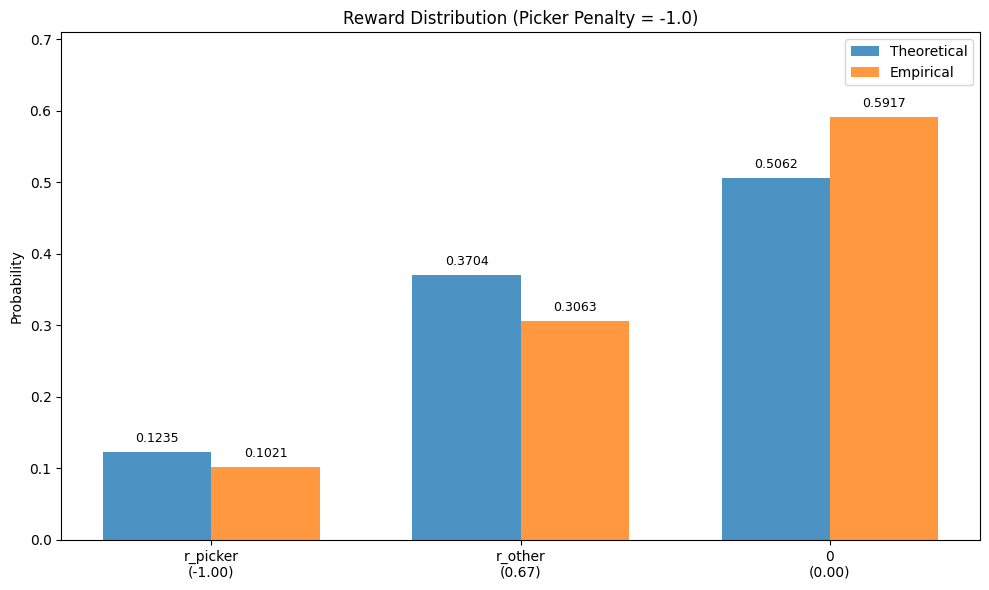

In [10]:
# Plot reward distribution comparison
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['r_picker', 'r_other', '0']
theory = [p_picker_theory, p_other_theory, p_zero_theory]
empirical = [p_picker_emp, p_other_emp, p_zero_emp]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, theory, width, label='Theoretical', alpha=0.8)
bars2 = ax.bar(x + width/2, empirical, width, label='Empirical', alpha=0.8)

ax.set_ylabel('Probability')
ax.set_title(f'Reward Distribution (Picker Penalty = {PICKER_PENALTY})')
ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n({v:.2f})' for l, v in zip(labels, [R_PICKER, R_OTHER, 0])])
ax.legend()
ax.set_ylim(0, max(max(theory), max(empirical)) * 1.2)

# Add value labels on bars
for bar, val in zip(bars1, theory):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', 
            ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, empirical):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Save results to CSV
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
output_file = output_dir / f"mc_verify_p{PICKER_PENALTY}_s{SEED}.csv"

# Prepare row
row = {
    'picker_penalty': PICKER_PENALTY,
    'seed': SEED,
    'n_agents': N_AGENTS,
    'p_hit': P_HIT,
    'gamma': GAMMA,
    'mc_trajectories': MC_TRAJECTORIES,
    'mc_depth': MC_DEPTH,
    'initial_positions': str(agent_positions),
    'initial_c': initial_actor,
    'initial_m': str(m.tolist()),
    'mean_analytical': mean_ana,
    'mean_mc': mean_mc,
    'mean_bias': mean_diff,
    'mean_bias_pct': mean_pct,
    'p_picker_theory': p_picker_theory,
    'p_picker_empirical': p_picker_emp,
    'p_other_theory': p_other_theory,
    'p_other_empirical': p_other_emp,
    'p_zero_theory': p_zero_theory,
    'p_zero_empirical': p_zero_emp,
}

# Add per-agent values
for i in range(N_AGENTS):
    row[f'agent_{i}_analytical'] = analytical_values[i]
    row[f'agent_{i}_mc'] = mc_values[i]
    row[f'agent_{i}_bias'] = mc_values[i] - analytical_values[i]

# Write to CSV (overwrite mode for single row per run)
df_row = pd.DataFrame([row])
df_row.to_csv(output_file, index=False)

print(f"\nResults saved to {output_file}")


Results saved to outputs/mc_verify_p-1.0_s42.csv
